In [1]:
import numpy as np
from implementations import *
from helpers import pca_reduction

In [2]:
from helpers import *

keep_columns = [
    "_AGEG5YR", "_AGE65YR", "_AGE80", "_BMI5CAT", "_RFBMI5", "_CHLDCNT", "_EDUCAG", "_INCOMG",
    "_SMOKER3", "_RFSMOK3", "DRNKANY5", "DROCDY3_", "_RFBING5", "_RFDRHV5", "_PAINDX1",
    "_PA150R2", "_PA300R2", "_PA30021", "_RACEG21", "_MRACE1", "_PRACE1", "_DRDXAR1",
    "_ASTHMS1", "_CASTHM1", "_LTASTH1", "_MICHD", "_RFCHOL", "BLOODCHO", "_CHOLCHK",
    "_RFHYPE5", "_HCVU651", "_RFHLTH", "_RAWRAKE", "_STSTR", "_STRWT", "_STSTR"
]

x_train, x_test, y_train, train_ids, test_ids = load_csv_data("data/dataset", max_rows=500, keep_columns=keep_columns)

In [3]:
tx = preprocess(x_train)

In [4]:
tx = pca_reduction(tx, 15)

In [5]:
tx_train_split, tx_test_split, y_train_split, y_test_split = split_data(tx, y_train)

In [91]:
y_train_split = np.where(y_train_split == -1, 0, y_train_split)
predictions = predict_classification_batch(tx_train_split, y_train_split, tx_test_split, 5)
predictions = np.where(predictions == 0, -1, predictions)

In [92]:
predictions

array([-1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

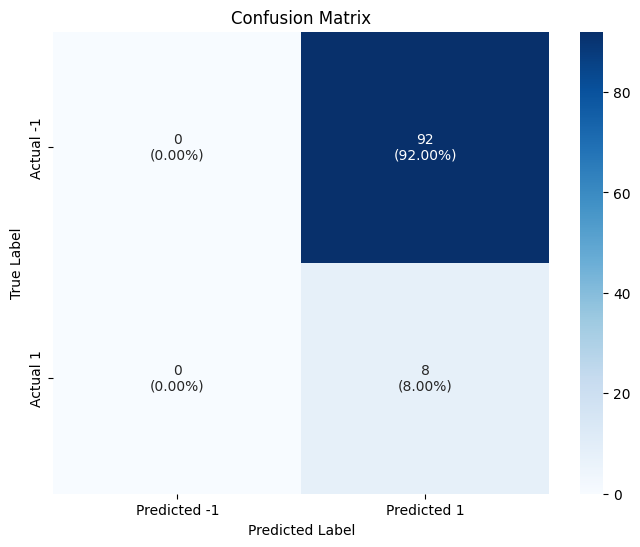

In [90]:
cm = create_confusion_matrix(y_test_split, predictions)

_ = cm_visualization(cm)